# 01 – Exploratory Data Analysis

This notebook explores the EmoPairCompete dataset: distributions of biosignal features
and questionnaire responses, correlations, and per-phase comparisons.

In [58]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

sns.set_theme(style='whitegrid')
%matplotlib inline

In [59]:
# Load all CSV files — column names are read directly from each file's header
data_dir = Path('../data/raw/data')

csv_files = glob.glob(str(data_dir / '**/*.csv'), recursive=True)
dfs = {}
for f in sorted(csv_files):
    key = Path(f).stem
    dfs[key] = pd.read_csv(f, index_col=0)
    print(f"{Path(f).relative_to(data_dir)}  →  {dfs[key].shape}")

# Main feature dataset
df = dfs['HR_data_2']
print(f'\nMain dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

HR_data.csv  →  (312, 67)
HR_data_2.csv  →  (312, 70)
dataset/D1_1/ID_1/round_1/phase1/BVP.csv  →  (28624, 2)
dataset/D1_1/ID_1/round_1/phase1/EDA.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/HR.csv  →  (448, 2)
dataset/D1_1/ID_1/round_1/phase1/TEMP.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_1/phase2/BVP.csv  →  (25081, 2)
dataset/D1_1/ID_1/round_1/phase2/EDA.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/HR.csv  →  (392, 2)
dataset/D1_1/ID_1/round_1/phase2/TEMP.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/response.csv  →  (1, 16)
dataset/D1_1/ID_1/round_1/phase3/BVP.csv  →  (23691, 2)
dataset/D1_1/ID_1/round_1/phase3/EDA.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/HR.csv  →  (370, 2)
dataset/D1_1/ID_1/round_1/phase3/TEMP.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_2/phase1/BVP.csv  →  (19565, 2)
dataset/D1_1/ID_1/round_2/phase1/EDA.csv  →  (1223, 2)
d

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


In [60]:
df.describe()

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,...,312.000000,312.000000,312.000000,312.000000,310.000000,312.000000,311.000000,311.000000,311.000000,310.000000
mean,78.549974,77.452869,6.545680,68.778365,92.451122,24307.558590,-0.054661,0.375978,-0.567952,0.518478,...,1.346154,1.057692,2.192308,1.221154,2.183871,1.381410,2.784566,1.051447,2.553055,2.912903
std,11.382695,12.093798,4.998885,9.341107,17.759683,4035.278119,1.671170,0.823875,0.391239,0.470043,...,0.617576,0.271719,1.037034,0.549014,1.027958,0.577199,1.113793,0.273430,1.173463,1.104050
min,57.606118,54.130000,0.834390,49.000000,67.200000,14853.260000,-1.644825,-2.230501,-3.366000,0.075000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,71.061238,69.971250,3.160342,62.192500,80.207500,21549.048750,-0.984473,-0.151022,-0.665208,0.292500,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000
50%,76.784284,75.600000,4.919862,67.565000,87.830000,23650.430000,-0.456978,0.361195,-0.457500,0.412500,...,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,3.000000,1.000000,2.000000,3.000000
75%,83.566296,83.108750,8.006694,73.805000,99.452500,26543.927500,0.216412,0.988498,-0.317500,0.613750,...,2.000000,1.000000,3.000000,1.000000,3.000000,2.000000,4.000000,1.000000,3.000000,4.000000
max,151.942434,167.950000,32.155396,111.070000,172.470000,46069.990000,12.510032,3.225347,-0.112500,6.202500,...,4.000000,3.000000,5.000000,4.000000,5.000000,3.000000,5.000000,4.000000,5.000000,5.000000


Find categorical variables

In [61]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)


['Round', 'Phase', 'raw_data_path', 'Team_ID', 'Cohort']


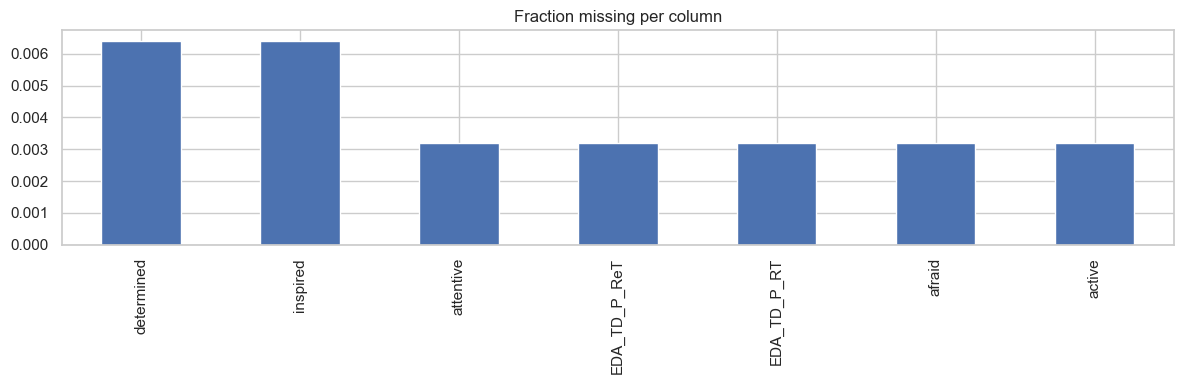

In [62]:
# Missing value summary
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', figsize=(12, 4), title='Fraction missing per column')
plt.tight_layout()
plt.savefig('../results/figures/missing_values.png', dpi=150)
plt.show()

In [63]:
print(df.isnull().sum().sum())

9


Replace numerical column missing values with means

In [64]:
df = df.fillna(df.mean(numeric_only=True))

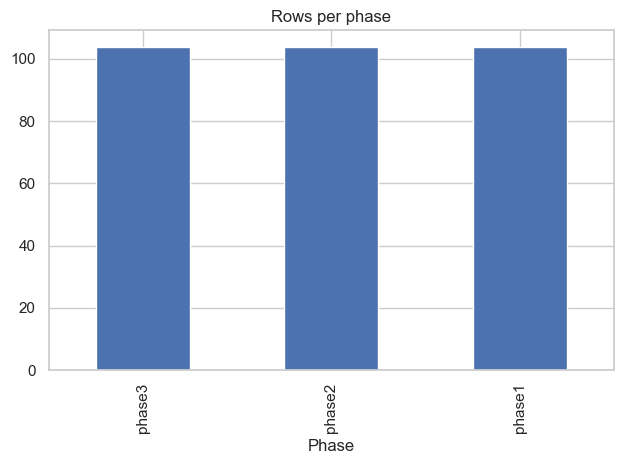

In [65]:
# Phase distribution
df['Phase'].value_counts().plot(kind='bar', title='Rows per phase')
plt.tight_layout()
plt.show()

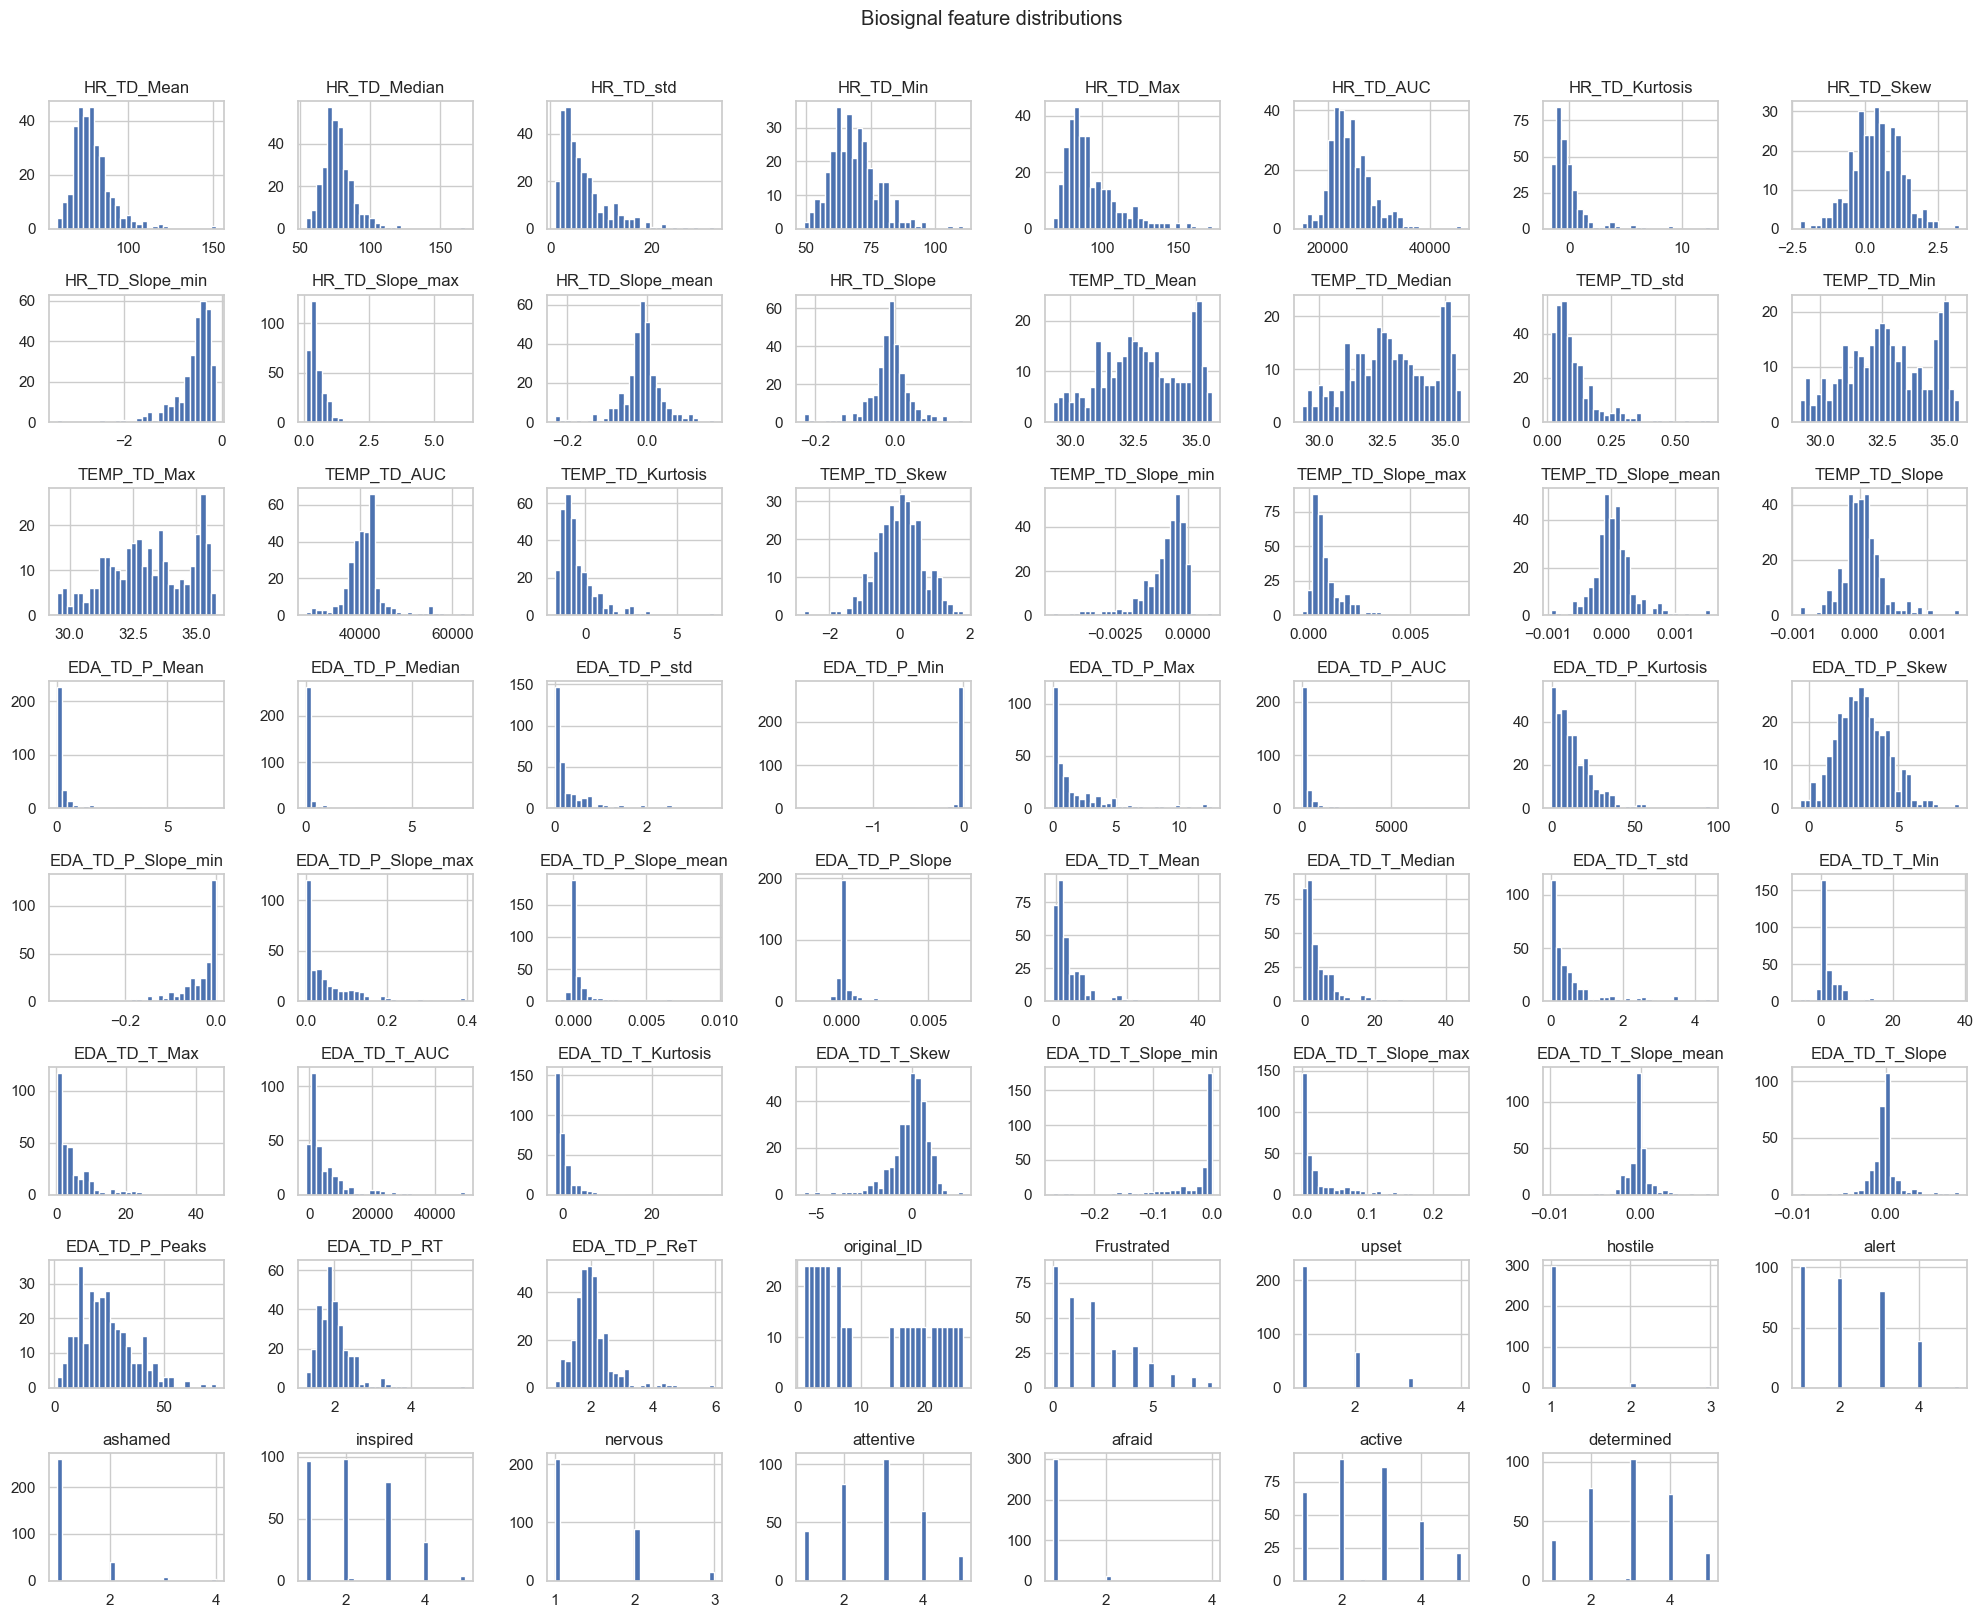

In [66]:
# Biosignal feature distributions — numeric columns, excluding metadata
meta_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort']
numeric_cols = df.select_dtypes(include='number').columns.tolist()
biosignal_cols = [c for c in numeric_cols if c not in meta_cols]

df[biosignal_cols].hist(bins=30, figsize=(20, 16))
plt.suptitle('Biosignal feature distributions', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/biosignal_distributions.png', dpi=150)
plt.show()

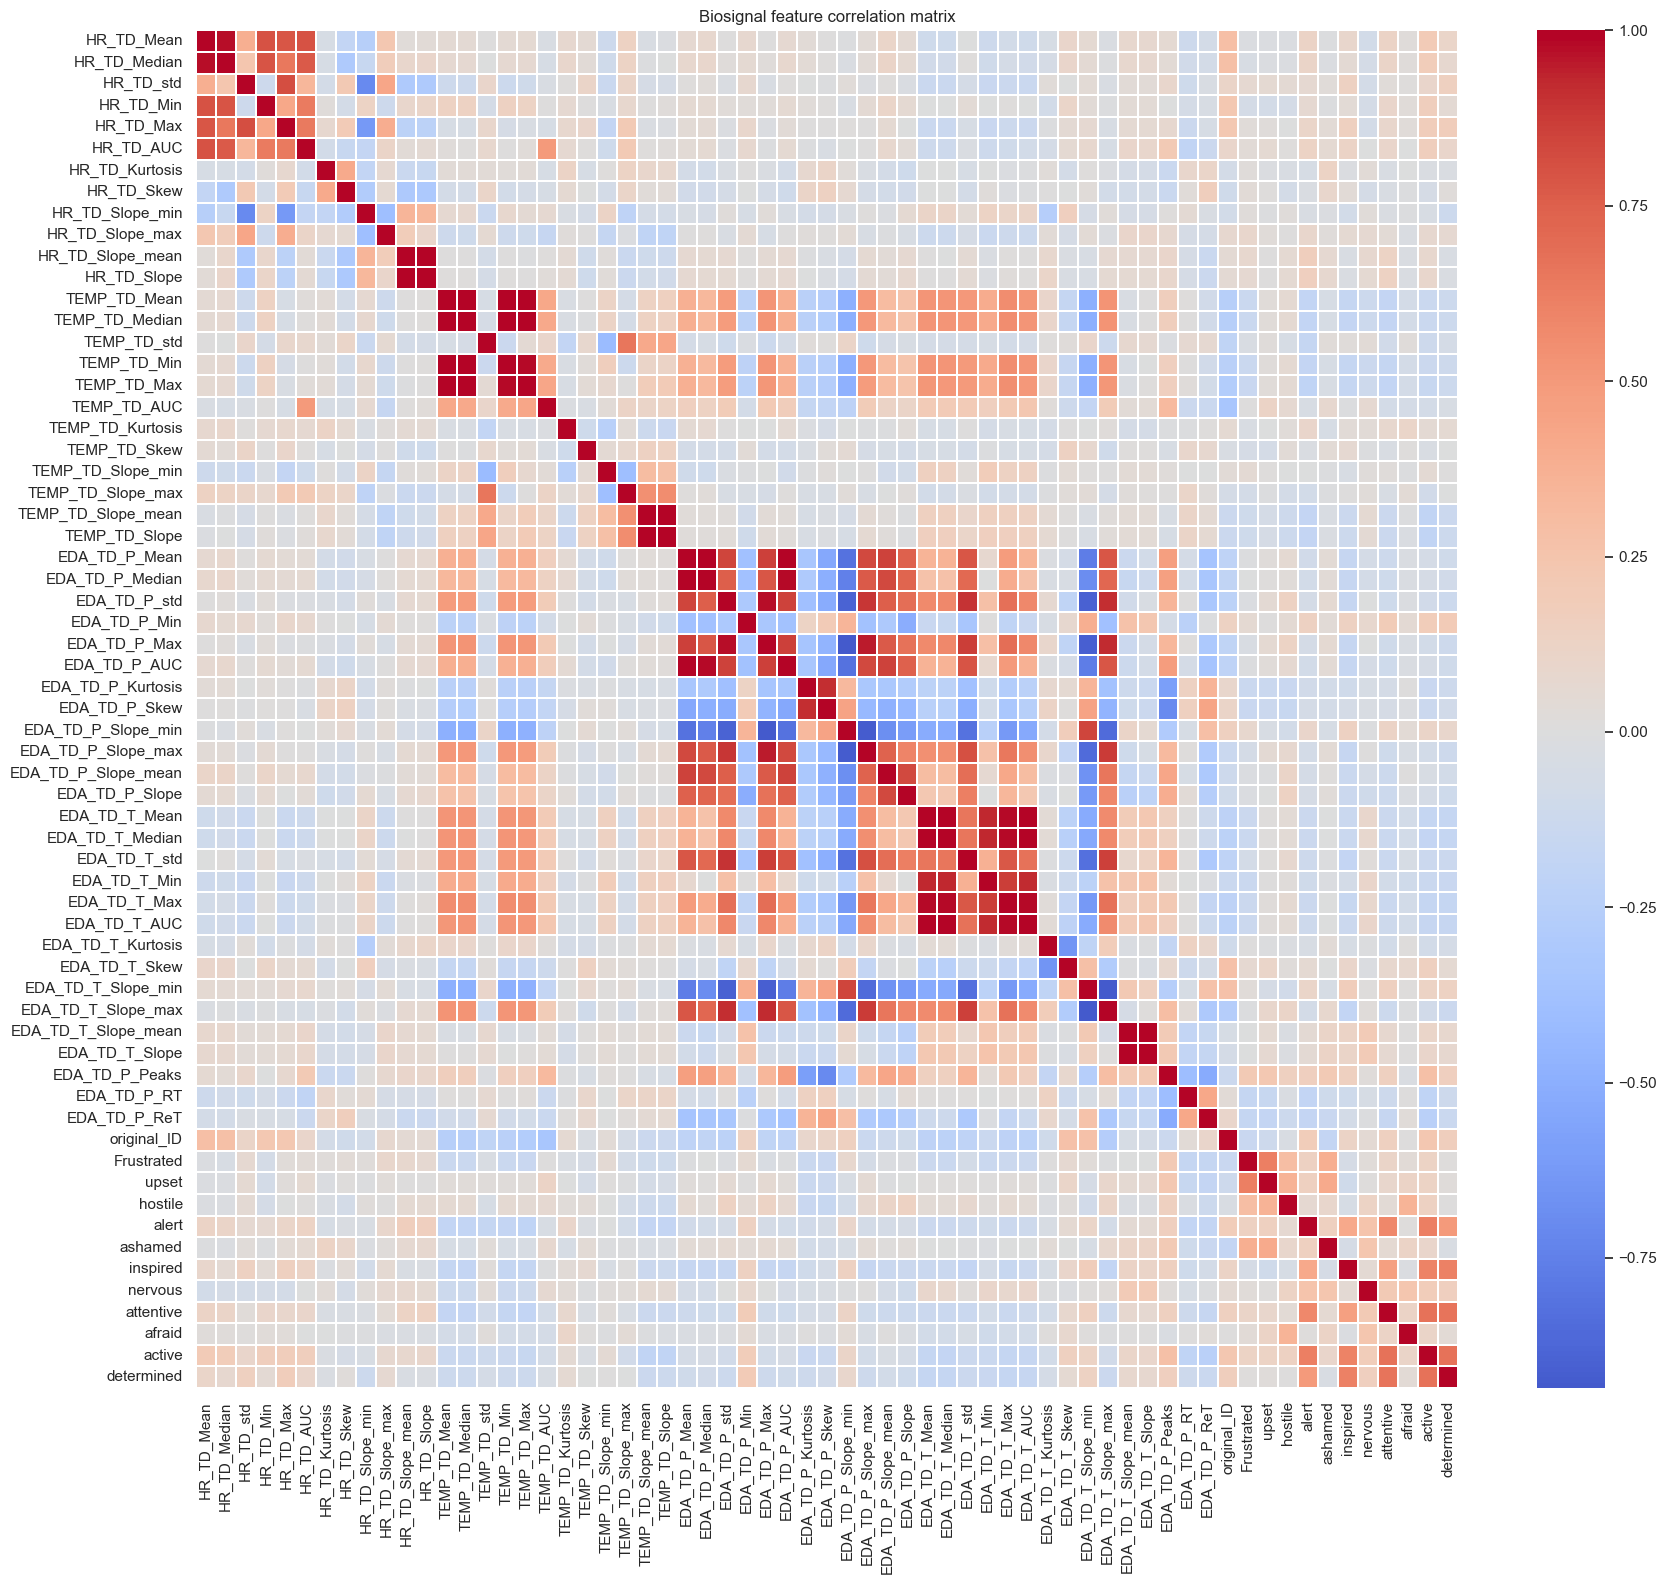

In [67]:
# Correlation heatmap — all numeric biosignal columns
corr = df[biosignal_cols].corr()
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Biosignal feature correlation matrix')
plt.tight_layout()
plt.savefig('../results/figures/biosignal_correlation.png', dpi=150)
plt.show()

One-hot-encode categorical variables

In [68]:
df = df.drop(columns=['raw_data_path', 'Team_ID'])
df = pd.get_dummies(df, columns=['Round', 'Phase', 'Cohort'])
df


,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,Round_round_4,Phase_phase1,Phase_phase2,Phase_phase3,Cohort_D1_1,Cohort_D1_2,Cohort_D1_3,Cohort_D1_4,Cohort_D1_5,Cohort_D1_6
0,78.663878,76.700,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.730000,0.9775,...,False,False,False,True,False,False,False,True,False,False
1,76.540732,76.610,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.360000,0.1900,...,False,False,True,False,False,False,False,True,False,False
2,78.173563,77.920,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.630000,0.3575,...,False,True,False,False,False,False,False,True,False,False
3,83.073688,83.880,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.465000,0.6500,...,False,False,False,True,False,False,False,True,False,False
4,72.281250,72.910,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.372500,0.3375,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,82.019065,78.830,8.794206,69.73,97.18,26244.705,-1.386324,0.251382,-0.517500,0.3525,...,True,False,True,False,False,False,False,False,True,False
308,103.274248,104.625,14.208117,68.13,125.52,31523.695,-0.338091,-0.521254,-0.962500,1.0875,...,True,True,False,False,False,False,False,False,True,False
309,99.065000,97.490,10.079197,86.55,119.75,28235.230,-0.740136,0.629730,-0.657500,0.9175,...,False,False,False,True,False,False,False,False,True,False
310,91.793354,97.180,19.234169,60.90,120.67,28909.835,-1.229115,-0.181431,-0.717500,0.9800,...,False,False,True,False,False,False,False,False,True,False


Save to processed

In [69]:
df.to_csv('../data/processed/HR_data_2.csv')